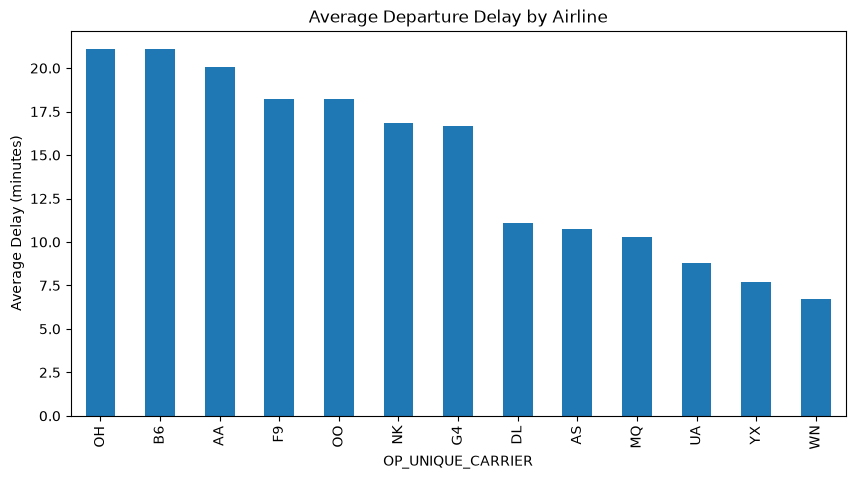

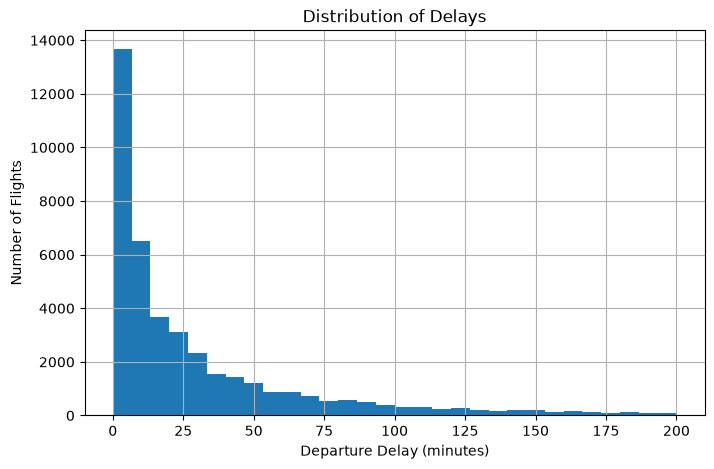

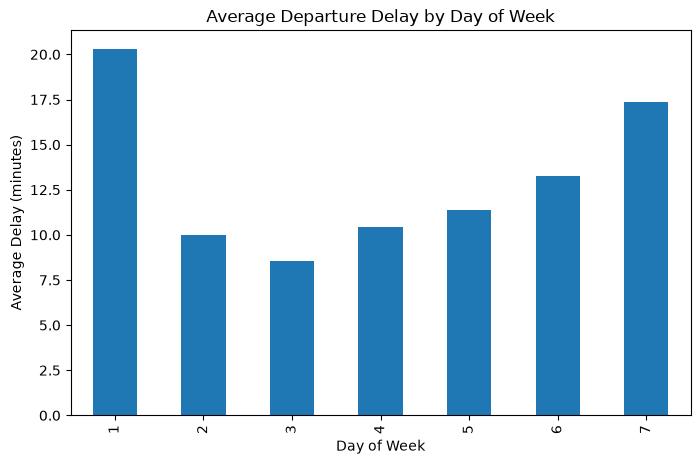

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data.csv",
    dtype={"CRS_DEP_TIME": str}
)


#This code filters the dataset down to 20% of the original (around 100,000 entries out of 500,000) 
#Flights are considered delayed if they are delayed by more than 15 minutes
df["Delayed"] = (df["DEP_DELAY"] > 15).astype(int)

#The proportion of delayed flights is preserved
sample, remainder = train_test_split(
    df,
    train_size=0.20,
    stratify=df["Delayed"],
    random_state=42
)

df = sample.copy()

#Preprocessing starts here
#Remove cancelled and diverted flights; they don't impact delay values
df = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()
#Scale numeric values where necessary
scaler = StandardScaler()

numeric = [
    "DISTANCE",
    "CRS_ELAPSED_TIME",
]

df[numeric] = scaler.fit_transform(df[numeric])

#Get departure hour
df["CRS_DEP_TIME"] = df["CRS_DEP_TIME"].str.zfill(4)
df["DEP_HOUR"] = df["CRS_DEP_TIME"].str[:2].astype(int)

df_clean = df.copy()

#Make a graph showing average delay by airline
avg_delay = (
    df.groupby("OP_UNIQUE_CARRIER")["DEP_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

avg_delay.plot(
    kind="bar",
    figsize=(10,5),
    title="Average Departure Delay by Airline"
)

plt.ylabel("Average Delay (minutes)")
plt.show()

#Make a graph showing distribution of delays
#Negative delays (early departures) and delays greater than 200 are not included to improve visualization 
delay = df[(df["DEP_DELAY"] >= 0) & (df["DEP_DELAY"] <= 200)]

plt.figure(figsize=(8,5))

delay["DEP_DELAY"].hist(bins=30)

plt.title("Distribution of Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

#Make a graph showing average delay for each day of the week
avg_day = df.groupby("DAY_OF_WEEK")["DEP_DELAY"].mean()

avg_day.plot(kind="bar", figsize=(8,5))
plt.title("Average Departure Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.show()
     



5-fold CV RMSE on training data (model selection, no test-set peeking):


  LinearRegression: 58.800 (+/- 2.475)


  Ridge: 58.800 (+/- 2.475)


  RandomForestRegressor: 59.415 (+/- 2.463)

Selected model (lowest CV RMSE): Ridge


Best params: {'alpha': 50.0}
Best CV RMSE after tuning: 58.799

Final held-out test performance (Ridge):
  MAE:  25.035
  MSE:  3583.443
  RMSE: 59.862
  R^2:  0.015

Saved regression_feature_importance.png


Saved regression_pred_vs_actual.png


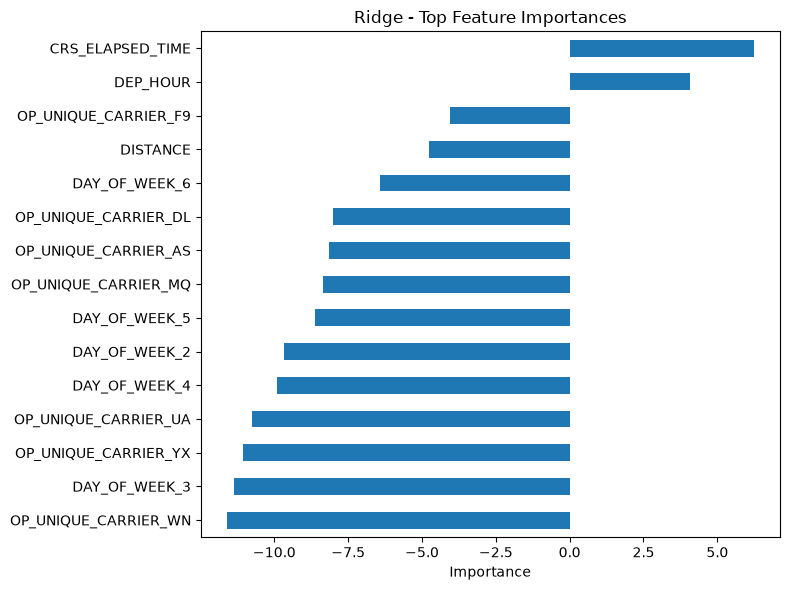

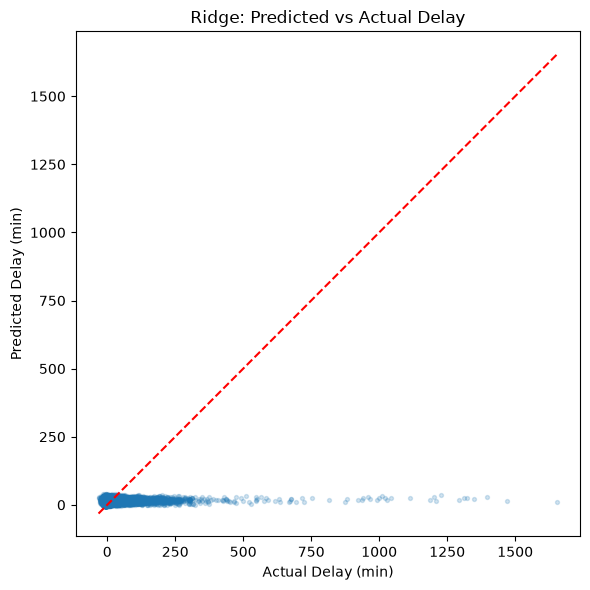

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

#Reuse the cleaned 20% sample
model_df = df_clean.copy()

#Features/Target
TARGET = "DEP_DELAY"
numeric_features = ["DISTANCE", "CRS_ELAPSED_TIME", "DEP_HOUR"]
categorical_features = ["OP_UNIQUE_CARRIER", "DAY_OF_WEEK", "MONTH"]
 
model_cols = numeric_features + categorical_features + [TARGET]
data = model_df[model_cols].dropna()
 
X = pd.get_dummies(data[numeric_features + categorical_features],
                    columns=categorical_features, drop_first=True)
y = data[TARGET]

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
 
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

#Cross validation on training-set
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
candidates = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv_scores = {}
print("5-fold CV RMSE on training data (model selection, no test-set peeking):")
for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    rmse = -scores.mean()
    cv_scores[name] = rmse
    print(f"  {name}: {rmse:.3f} (+/- {scores.std():.3f})")
 
best_name = min(cv_scores, key=cv_scores.get)
print(f"\nSelected model (lowest CV RMSE): {best_name}")
 
#Hyperparameter tuning for model using training-set
if best_name == "RandomForestRegressor":
    param_grid = {"n_estimators": [100, 200], "max_depth": [8, 12, None]}
    grid = GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
elif best_name == "Ridge":
    param_grid = {"alpha": [0.1, 1.0, 10.0, 50.0]}
    grid = GridSearchCV(
        Ridge(random_state=RANDOM_STATE), param_grid, cv=cv,
        scoring="neg_root_mean_squared_error",
    )
else:
    grid = None
 
if grid is not None:
    grid.fit(X_train, y_train)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV RMSE after tuning: {-grid.best_score_:.3f}")
    best_model = grid.best_estimator_
else:
    best_model = candidates[best_name]
    best_model.fit(X_train, y_train)
    
#Final eval with test set
final_preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, final_preds)
mse = mean_squared_error(y_test, final_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_preds)

print(f"\nFinal held-out test performance ({best_name}):")
print(f"  MAE:  {mae:.3f}")
print(f"  MSE:  {mse:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R^2:  {r2:.3f}")

#Feature importances
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(best_model.coef_, index=X.columns)
    importances = importances.reindex(
        importances.abs().sort_values(ascending=False).index
    ).head(15)
else:
    importances = None
 
if importances is not None:
    plt.figure(figsize=(8, 6))
    importances.sort_values().plot(kind="barh")
    plt.title(f"{best_name} - Top Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("regression_feature_importance.png")
    print("\nSaved regression_feature_importance.png")
    
#Predicted vs. actual plotted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_preds, alpha=0.2, s=8)
lims = [min(y_test.min(), final_preds.min()), max(y_test.max(), final_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")
plt.title(f"{best_name}: Predicted vs Actual Delay")
plt.tight_layout()
plt.savefig("regression_pred_vs_actual.png")
print("Saved regression_pred_vs_actual.png")